# Adapted RAG Pipeline — Nutritional Management of Diabetes Mellitus


In [ ]:
"""                     Diabetes Nutrition PDF
                             │
                             ▼
                   PDF Loading & Parsing
                             │
                             ▼
                  Text Cleaning & Filtering
                             │
                             ▼
             Metadata + Document Statistics
                             │
                             ▼
             Adaptive Chunking + Validation
                             │
                             ▼
        ┌────────────────────┴────────────────────┐
        ▼                                         ▼
   TF-IDF Index                              BM25 Index
        │                                         │
        └──────────────┬──────────────────────────┘
                       ▼
               Hybrid Lexical Retrieval
                       │
                       ▼
               Query Expansion
                       │
                       ▼
          SentenceTransformer Embeddings
                       │
                       ▼
               Semantic Retrieval
                       │
                       ▼
              Hybrid Retrieval Fusion
                       │
                       ▼
                  Cross-Encoder Reranker
                       │
                       ▼
              Context Construction
                       │
                       ▼
         Duplicate Context Removal
                       │
                       ▼
                Prompt Construction
                       │
                       ▼
              Ollama (DeepSeek-R1)
                       │
                       ▼
        Grounded Answer + Citations
                       │
                       ▼
          Confidence Score + Evaluation """

In [1]:
pip install docling

Note: you may need to restart the kernel to use updated packages.


## Load libraries

In [2]:
import pandas as pd
from docling.document_converter import DocumentConverter
import re
from collections import Counter
import os
from IPython.display import display, Markdown
from docling.datamodel.pipeline_options import PdfPipelineOptions
from IPython.display import display





c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from pathlib import Path

for p in Path(r"C:\Users\Admin").rglob("Nutritional Management of Diabetes Mellitus*.pdf"):
    print(p)

C:\Users\Admin\Desktop\safaa samy second term download\download4\New folder (3)\Nutritional Management of Diabetes Mellitus - 2003 - Frost.pdf
C:\Users\Admin\Desktop\safaa samy second term download\download4\New folder (3) - Copy\Nutritional Management of Diabetes Mellitus - 2003 - Frost.pdf
C:\Users\Admin\Desktop\safaa samy second term download\download4\nutration\Nutritional Management of Diabetes Mellitus - 2003 - Frost.pdf
C:\Users\Admin\Downloads\New folder (3) - Copy\Nutritional Management of Diabetes Mellitus - 2003 - Frost.pdf


## Setup PDF Loader 

In [4]:
from docling.document_converter import DocumentConverter


PDF_PATH = r"C:\Users\Admin\Desktop\safaa samy second term download\download4\New folder (3) - Copy\Nutritional Management of Diabetes Mellitus - 2003 - Frost.pdf"


# ==================================================
# Initialize Docling Converter
# ==================================================

converter = DocumentConverter()


# ==================================================
# PDF Loader
# ==================================================

def load_pdf_document(pdf_path):

    result = converter.convert(pdf_path)

    doc = result.document

    text_parts = []

    for item, _ in doc.iterate_items():

        if hasattr(item, "text") and item.text:

            text_parts.append(
                item.text.strip()
            )


    raw_text = "\n".join(text_parts)


    return {
        "source_file": pdf_path,
        "raw_text": raw_text,
        "char_count": len(raw_text),
        "word_count": len(raw_text.split())
    }



# ==================================================
# Run Loader
# ==================================================

pdf_document = load_pdf_document(PDF_PATH)


print("="*60)
print("PDF DOCUMENT SUMMARY")
print("="*60)

print(
    "Characters:",
    pdf_document["char_count"]
)

print(
    "Words:",
    pdf_document["word_count"]
)


print("\nFIRST 1000 CHARACTERS")
print("="*60)

print(
    pdf_document["raw_text"][:1000]
)

[INFO] 2026-07-21 17:56:08,012 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-21 17:56:08,016 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-21 17:56:08,022 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-07-21 17:56:08,022 [RapidOCR] main.py:50: Using C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-07-21 17:56:08,153 [RapidOCR] base.py:23: Using engine_name: torch
[INFO] 2026-07-21 17:56:08,153 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-07-21 17:56:08,153 [RapidOCR] download_file.py:60: File exists and is valid: C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\rapidocr\models\ch_ptocr_mobile_v2.0_cls_mobile.pth
[INFO] 2026-07-21 17:56:08,153 [RapidOCR] main.py:50: Using C:\Users\Admin\AppData\Loca

PDF DOCUMENT SUMMARY
Characters: 687987
Words: 102580

FIRST 1000 CHARACTERS
Nutritional Management of Diabetes Mellitus
Other titles in theWiley Diabetes in Practice Series
Diabetes in Pregnancy: An International Approach to Diagnosis and Management Edited byAnne Dornhorst and David R. Hadden (047196204X)
Diabetic Complications Edited by Ken Shaw (0471966789)
Childhood and Adolescent Diabetes Edited by Simon Court and Bill Lamb (0471970034)
Hypoglycaemia in Clinical Diabetes Brian M. Frier and B. Miles Fisher (0471982644)
Exercise and Sport in Diabetes Edited by Bill Burr and Dinesh Nagi (0471984965)
Psychology of Diabetes Care Edited by Frank Snoek andT . Chas Skinner (0471977039)
The Foot in Diabetes Third Edition Edited byA. J. M. Boulton, Henry Connor and P . R. Cavanagh (0471489743)
Nutritional Management of Diabetes Mellitus Edited by Gary Frost, Anne Dornhorst and Robert Moses (0471497517)
Nutritional Management of Diabetes Mellitus
Edited by
Gary Frost
Hammersmith Hospital and

In [5]:
comparison_df = pd.DataFrame({
    "Parser": [
        "pypdf",
        "Docling"
    ],
    "Total Characters": [
        653980,
        687785
    ],
    "Total Words": [
        100974,
        102550
    ]
})

comparison_df["Character Increase (%)"] = (
    (comparison_df["Total Characters"] - comparison_df.loc[0, "Total Characters"])
    / comparison_df.loc[0, "Total Characters"] * 100
)

comparison_df["Word Increase (%)"] = (
    (comparison_df["Total Words"] - comparison_df.loc[0, "Total Words"])
    / comparison_df.loc[0, "Total Words"] * 100
)

comparison_df

,Parser,Total Characters,Total Words,Character Increase (%),Word Increase (%)
0,pypdf,653980,100974,0.000000,0.000000
1,Docling,687785,102550,5.169118,1.560798


In [6]:
from docling.document_converter import (
    DocumentConverter,
    PdfFormatOption,
)
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

pipeline_options = PdfPipelineOptions()

pipeline_options.generate_picture_images = True
pipeline_options.do_ocr = False

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)

result = converter.convert(PDF_PATH)

doc = result.document

print("Pictures:", len(doc.pictures))

picture = doc.pictures[0]

print(dir(picture))

Pictures: 14
['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__class_vars__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__fields_set__', '__format__', '__ge__', '__get_pydantic_core_schema__', '__get_pydantic_json_schema__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__pretty__', '__private_attributes__', '__pydantic_complete__', '__pydantic_computed_fields__', '__pydantic_core_schema__', '__pydantic_custom_init__', '__pydantic_decorators__', '__pydantic_extra__', '__pydantic_extra_info__', '__pydantic_fields__', '__pydantic_fields_set__', '__pydantic_generic_metadata__', '__pydantic_init_subclass__', '__pydantic_on_complete__', '__pydantic_parent_namespace__', '__pydantic_post_init__', '__pydantic_private__', '__pydantic_root_model__', '__pydantic_serializer__', '__py

Picture: 1
Page: 2


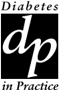

Picture: 2
Page: 3


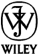

Picture: 3
Page: 33


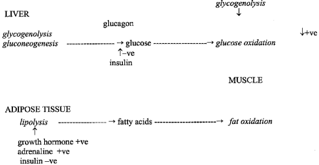

Picture: 4
Page: 44


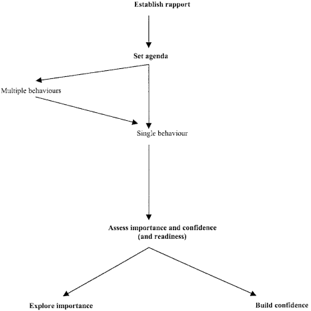

Picture: 5
Page: 49


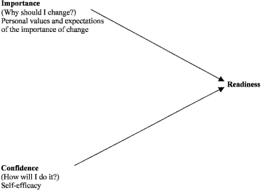

Picture: 6
Page: 72


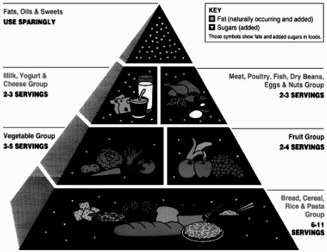

Picture: 7
Page: 73


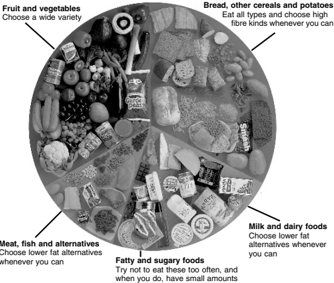

Picture: 8
Page: 164


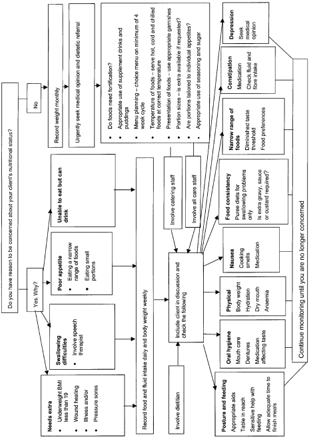

Picture: 9
Page: 182


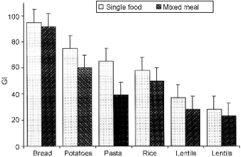

Picture: 10
Page: 182


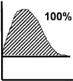

Picture: 11
Page: 182


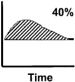

Picture: 12
Page: 185


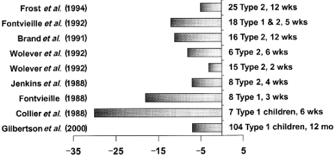

Picture: 13
Page: 209


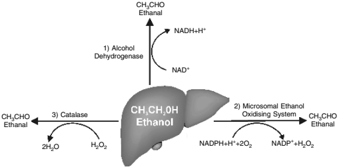

Picture: 14
Page: 210


In [7]:
from IPython.display import display

for i, picture in enumerate(doc.pictures, start=1):

    print("=" * 50)
    print("Picture:", i)
    print("Page:", picture.prov[0].page_no)

    try:
        img = picture.get_image(doc)

        if img is not None:
            display(img)
        else:
            print("No image returned")

    except Exception as e:
        print(e)

In [8]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions

pipeline_options = PdfPipelineOptions()

# لا تشغل OCR
pipeline_options.do_ocr = False

# لا تولد صور طالما لا تحتاجينها الآن
pipeline_options.generate_picture_images = False

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(
            pipeline_options=pipeline_options
        )
    }
)
result = converter.convert(PDF_PATH)

## Stage 2: Text Cleaning


In [9]:
import re

# ==================================================
# PDF / Docling Cleaning
# ==================================================

def clean_document(text):
    """
    Expert cleaning pipeline for Docling output.
    Preserves semantic structure while removing PDF artifacts.
    """

    # ------------------------------------------------
    # 1. Normalize line endings
    # ------------------------------------------------
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # ------------------------------------------------
    # 2. Join hyphenated words
    # nutri-\ntion -> nutrition
    # ------------------------------------------------
    text = re.sub(
        r'(\w+)-\s*\n\s*(\w+)',
        r'\1\2',
        text
    )

    # ------------------------------------------------
    # 3. Remove HTML comments generated by Docling
    # <!-- image -->
    # ------------------------------------------------
    text = re.sub(
        r'<!--.*?-->',
        '',
        text,
        flags=re.DOTALL
    )

    # ------------------------------------------------
    # 4. Remove URLs
    # ------------------------------------------------
    text = re.sub(
        r'https?://\S+',
        '',
        text
    )

    # ------------------------------------------------
    # 5. Remove email addresses
    # ------------------------------------------------
    text = re.sub(
        r'\S+@\S+',
        '',
        text
    )

    # ------------------------------------------------
    # 6. Remove download/license notices
    # ------------------------------------------------
    license_patterns = [

        r'Downloaded from.*',
        r'See the Terms and Conditions.*',
        r'OA articles are governed by.*',

    ]

    for p in license_patterns:

        text = re.sub(
            p,
            '',
            text,
            flags=re.IGNORECASE
        )

    # ------------------------------------------------
    # 7. Remove repeated page numbers
    # ------------------------------------------------
    text = re.sub(
        r'(?m)^\s*\d+\s*$',
        '',
        text
    )

    # ------------------------------------------------
    # 8. Remove isolated Roman numerals
    # ------------------------------------------------
    text = re.sub(
        r'(?m)^\s*[IVXLCDMivxlcdm]+\s*$',
        '',
        text
    )

    # ------------------------------------------------
    # 9. Normalize spaces
    # ------------------------------------------------
    text = re.sub(
        r'[ \t]+',
        ' ',
        text
    )

    # ------------------------------------------------
    # 10. Remove spaces before newline
    # ------------------------------------------------
    text = re.sub(
        r'[ \t]+\n',
        '\n',
        text
    )

    # ------------------------------------------------
    # 11. Collapse blank lines
    # ------------------------------------------------
    text = re.sub(
        r'\n{3,}',
        '\n\n',
        text
    )

    return text.strip()


# ==================================================
# Run Cleaning
# ==================================================

cleaned_text = clean_document(pdf_document["raw_text"])

print("="*60)
print("CLEANING SUMMARY")
print("="*60)
print(f"Characters : {len(cleaned_text):,}")
print(f"Words      : {len(cleaned_text.split()):,}")

print("\n" + "="*60)
print("DOCUMENT PREVIEW")
print("="*60)

print(cleaned_text[:2000])

CLEANING SUMMARY
Characters : 575,769
Words      : 88,191

DOCUMENT PREVIEW
Nutritional Management of Diabetes Mellitus
Other titles in theWiley Diabetes in Practice Series
Diabetes in Pregnancy: An International Approach to Diagnosis and Management Edited byAnne Dornhorst and David R. Hadden (047196204X)
Diabetic Complications Edited by Ken Shaw (0471966789)
Childhood and Adolescent Diabetes Edited by Simon Court and Bill Lamb (0471970034)
Hypoglycaemia in Clinical Diabetes Brian M. Frier and B. Miles Fisher (0471982644)
Exercise and Sport in Diabetes Edited by Bill Burr and Dinesh Nagi (0471984965)
Psychology of Diabetes Care Edited by Frank Snoek andT . Chas Skinner (0471977039)
The Foot in Diabetes Third Edition Edited byA. J. M. Boulton, Henry Connor and P . R. Cavanagh (0471489743)
Nutritional Management of Diabetes Mellitus Edited by Gary Frost, Anne Dornhorst and Robert Moses (0471497517)
Nutritional Management of Diabetes Mellitus
Edited by
Gary Frost
Hammersmith Hospital and 

In [10]:
import re


# ==================================================
# Remove Front Matter from Book
# ==================================================

def remove_front_matter(text):

    """
    Remove publisher front matter from Docling extracted text.
    Keep the actual book content starting from Introduction.
    """

    start_pattern = r"\nIntroduction\n"

    match = re.search(
        start_pattern,
        text,
        flags=re.IGNORECASE
    )


    if match:

        text = text[
            match.start():
        ]


    return text.strip()

# Cleaning
cleaned_text = clean_document(
    pdf_document["raw_text"]
)


# Remove front matter
cleaned_text = remove_front_matter(
    cleaned_text
)


print("="*60)
print("AFTER FRONT MATTER REMOVAL")
print("="*60)

print(cleaned_text[:2000])

AFTER FRONT MATTER REMOVAL
Introduction
The Ancient Greeks were the first to advocate diet and lifestyle management for people with diabetes. Until the discovery and use of insulin in the 1920s and suphonylureas in the 1940s, diet and lifestyle intervention were the only treatment options available. For people with Type 1 diabetes this was woefully ineffective and consisted of near starvation diets imposed on already severely malnourished individuals. While such diets may have prolonged life by a few months, an inevitable early death from ketoacidosis was all too often replaced with death from infections due to the severe malnutrition and other comorbidities. The introduction of insulin radically reduced the death rates from ketoacidosis and problems associated with malnutrition, however, survival brought other lethal problems in the form of microvascular and macrovascular disease.
The dietary management of Type 1 diabetes over the last 80 years has had to adapt to the many changes in 

In [11]:
text_items = []

for item, _ in doc.iterate_items():

    if hasattr(item, "text") and item.text:

        text_items.append(item.text.strip())

print("Total Text Items:", len(text_items))

Total Text Items: 2597


In [12]:
from IPython.display import display, HTML

start_item = 300   
end_item = 310     


# ==================================================
# Build Before / After Text
# ==================================================

before = "\n\n".join(
    text_items[start_item:end_item]
)

after = clean_document(before)


# ==================================================
# Display
# ==================================================

display(HTML("""
<style>
.output pre {
    font-size: 10px;
    line-height: 1.3;
    max-height: 500px;
    overflow-y: auto;
}
</style>
"""))


print("=" * 80)
print(f"ITEMS {start_item} - {end_item}")
print("=" * 80)


print("\nBEFORE CLEANING")
print("-" * 80)

display(HTML(
    f"<pre>{before}</pre>"
))


print("\nAFTER CLEANING")
print("-" * 80)

display(HTML(
    f"<pre>{after}</pre>"
))

ITEMS 300 - 310

BEFORE CLEANING
--------------------------------------------------------------------------------



AFTER CLEANING
--------------------------------------------------------------------------------


## Stage 3: Document Statistics 


In [13]:
import numpy as np


def compute_document_statistics(text_items):

    word_counts = [
        len(item.split())
        for item in text_items
        if item.strip()
    ]

    return {

        "num_text_items": len(text_items),

        "total_words": int(sum(word_counts)),

        "total_chars": int(
            sum(len(item) for item in text_items)
        ),

        "avg_words_per_item": round(
            float(np.mean(word_counts)), 1
        ) if word_counts else 0,

        "median_words_per_item": round(
            float(np.median(word_counts)), 1
        ) if word_counts else 0,

        "min_words_per_item": int(
            min(word_counts)
        ) if word_counts else 0,

        "max_words_per_item": int(
            max(word_counts)
        ) if word_counts else 0,

        "items_low_content": int(
            sum(1 for wc in word_counts if wc < 20)
        )
    }



# ==================================================
# Run Statistics
# ==================================================

stats = compute_document_statistics(text_items)


print("=" * 50)
print("DOCUMENT STATISTICS")
print("=" * 50)


for key, value in stats.items():
    print(f"{key:<30}: {value}")

DOCUMENT STATISTICS
num_text_items                : 2597
total_words                   : 102550
total_chars                   : 685189
avg_words_per_item            : 39.5
median_words_per_item         : 24.0
min_words_per_item            : 1
max_words_per_item            : 301
items_low_content             : 1089


In [14]:
def compare_before_after(raw_items, cleaned_items):

    before_words = sum(
        len(item.split())
        for item in raw_items
        if item.strip()
    )

    after_words = sum(
        len(item.split())
        for item in cleaned_items
        if item.strip()
    )


    print("=" * 50)
    print("CLEANING SUMMARY")
    print("=" * 50)

    print(f"Words Before Cleaning : {before_words:,}")
    print(f"Words After Cleaning  : {after_words:,}")
    print(f"Removed Words         : {before_words-after_words:,}")

    if before_words > 0:
        print(
            f"Retention Rate        : {(after_words/before_words)*100:.2f}%"
        )


# ==================================================
# Prepare Cleaned Text Items
# ==================================================

cleaned_items = [
    clean_document(item)
    for item in text_items
]


# ==================================================
# Run Comparison
# ==================================================

compare_before_after(
    text_items,
    cleaned_items
)

CLEANING SUMMARY
Words Before Cleaning : 102,550
Words After Cleaning  : 88,089
Removed Words         : 14,461
Retention Rate        : 85.90%


## Stage 6: Adaptive Chunking
.

In [15]:
import re
import pandas as pd


# ==================================================
# Semantic Topic-aware Chunking
# ==================================================

def semantic_chunk_markdown(
    text,
    target_words=180,
    overlap_words=30,
    min_chunk_words=80
):
    """
    Topic-aware semantic chunking.

    Improvements:
    1. Preserve section boundaries.
    2. Never merge different headings.
    3. Merge paragraphs only inside the same section.
    4. Small overlap.
    5. Split only oversized paragraphs.
    """

    text = re.sub(r"\r\n", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    # ------------------------------------------------
    # Build sections
    # ------------------------------------------------

    sections = []

    current_heading = "General"

    current_paragraphs = []

    for part in text.split("\n\n"):

        part = part.strip()

        if not part:
            continue

        if part.startswith("#"):

            if current_paragraphs:

                sections.append(
                    (
                        current_heading,
                        current_paragraphs
                    )
                )

            current_heading = part

            current_paragraphs = []

            continue

        current_paragraphs.append(part)

    if current_paragraphs:

        sections.append(
            (
                current_heading,
                current_paragraphs
            )
        )

    # ------------------------------------------------
    # Chunk each section independently
    # ------------------------------------------------

    chunks = []

    for heading, paragraphs in sections:

        current_chunk = []

        current_words = 0

        for para in paragraphs:

            block = heading + "\n\n" + para

            words = block.split()

            # ----------------------------------------
            # Oversized paragraph
            # ----------------------------------------

            if len(words) > target_words:

                if current_chunk:

                    chunks.append("\n\n".join(current_chunk))

                    current_chunk = []

                    current_words = 0

                stride = target_words - overlap_words

                for start in range(0, len(words), stride):

                    piece = words[start:start + target_words]

                    if len(piece) >= min_chunk_words:

                        chunks.append(" ".join(piece))

                continue

            # ----------------------------------------
            # Normal merge
            # ----------------------------------------

            if current_words + len(words) <= target_words:

                current_chunk.append(block)

                current_words += len(words)

            else:

                chunks.append("\n\n".join(current_chunk))

                overlap = " ".join(
                    " ".join(current_chunk).split()[-overlap_words:]
                )

                current_chunk = [overlap, block]

                current_words = (
                    len(overlap.split()) +
                    len(words)
                )

        if current_chunk:

            chunks.append("\n\n".join(current_chunk))

    # ------------------------------------------------
    # DataFrame
    # ------------------------------------------------

    records = []

    for i, chunk in enumerate(chunks, start=1):

        records.append({

            "chunk_id": f"chunk_{i:04d}",

            "chunk_text": chunk,

            "word_count": len(chunk.split())

        })

    return pd.DataFrame(records)

In [16]:
# ==================================================
# DOCUMENT SEMANTIC CHUNKING SUMMARY
# ==================================================

chunks = semantic_chunk_markdown(
    cleaned_text,
    target_words=400,
    overlap_words=80,
    min_chunk_words=80
)


# Convert list to DataFrame if needed
if isinstance(chunks, list):
    chunks_df = pd.DataFrame(chunks)
else:
    chunks_df = chunks.copy()


# Add chunk_id if missing
if "chunk_id" not in chunks_df.columns:
    chunks_df.insert(
        0,
        "chunk_id",
        [
            f"chunk_{i:04d}"
            for i in range(1, len(chunks_df)+1)
        ]
    )

# Add metadata

chunks_df["source_file"] = PDF_PATH.split("\\")[-1]

chunks_df["publication_year"] = 2003


# Add char count if missing
if "char_count" not in chunks_df.columns:
    chunks_df["char_count"] = (
        chunks_df["chunk_text"]
        .apply(len)
    )


print("="*60)
print("SEMANTIC CHUNKING SUMMARY")
print("="*60)


word_counts = chunks_df["word_count"]


print(f"Generated Chunks    : {len(chunks_df)}")
print(f"Average Words       : {word_counts.mean():.1f}")
print(f"Median Words        : {word_counts.median():.1f}")
print(f"Min Words           : {word_counts.min()}")
print(f"Max Words           : {word_counts.max()}")


display(
    chunks_df[
        [
            "chunk_id",
            "word_count",
            "char_count",
            "chunk_text"
        ]
    ].head(4)
)

SEMANTIC CHUNKING SUMMARY
Generated Chunks    : 312
Average Words       : 332.5
Median Words        : 400.0
Min Words           : 83
Max Words           : 473


,chunk_id,word_count,char_count,chunk_text
0,chunk_0001,400,2612,General Introduction The Ancient Greeks were t...
1,chunk_0002,247,1609,authoritarian physicians towards trying to ach...
2,chunk_0003,180,1272,General\n\nNutritional Recommendations in Diab...
3,chunk_0004,370,2402,have now been superseded by recommendations fr...


## Stage 6: Chunk Quality Validation 

In [17]:
#Quality Inspection

print("=" * 60)
print("SEARCHING FOR REAL PDF ARTIFACTS")
print("=" * 60)

count = 0

# Detect repeated PDF extraction artifacts
artifact_pattern = re.compile(r"(?:\s/[CF]\d+\s*){8,}")

for idx, row in chunks_df.iterrows():

    text = row["chunk_text"]

    if artifact_pattern.search(text):

        count += 1

        print(f"Chunk Index: {idx}")
        print(text[:300])
        print("-" * 40)

print(f"Found: {count}")

SEARCHING FOR REAL PDF ARTIFACTS
Found: 0


In [18]:
""" patterns = {
    "Downloaded from": r"Downloaded from",
    "Terms": r"Terms and Conditions",
    "ISBN": r"ISBN",
    "Wiley": r"John Wiley|Wiley",
    "URLs": r"https?://",
    "Emails": r"\S+@\S+"
}


for name, pattern in patterns.items():

    count = chunks_df["chunk_text"].str.contains(
        pattern,
        regex=True,
        case=False,
        na=False
    ).sum()

    print(f"{name:<20}: {count}") """

<>:7: SyntaxWarning: invalid escape sequence '\S'
<>:7: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Admin\AppData\Local\Temp\ipykernel_7008\3654852647.py:7: SyntaxWarning: invalid escape sequence '\S'
  "Emails": r"\S+@\S+"


' patterns = {\n    "Downloaded from": r"Downloaded from",\n    "Terms": r"Terms and Conditions",\n    "ISBN": r"ISBN",\n    "Wiley": r"John Wiley|Wiley",\n    "URLs": r"https?://",\n    "Emails": r"\\S+@\\S+"\n}\n\n\nfor name, pattern in patterns.items():\n\n    count = chunks_df["chunk_text"].str.contains(\n        pattern,\n        regex=True,\n        case=False,\n        na=False\n    ).sum()\n\n    print(f"{name:<20}: {count}") '

In [19]:
""" import re


FRONT_MATTER_PATTERNS = [
    r"copyright",
    r"john wiley",
    r"wiley",
    r"isbn",
    r"cataloguing",
    r"library of congress",
    r"printed and bound",
    r"all rights reserved",
]


def remove_front_matter_chunks(chunks_df):

    mask = []

    for text in chunks_df["chunk_text"]:

        text_lower = text.lower()

        remove = any(
            re.search(pattern, text_lower)
            for pattern in FRONT_MATTER_PATTERNS
        )

        mask.append(not remove)

    filtered_df = chunks_df[mask].reset_index(drop=True)

    print("="*60)
    print("FRONT MATTER CHUNK FILTER")
    print("="*60)
    print("Before :", len(chunks_df))
    print("After  :", len(filtered_df))
    print("Removed:", len(chunks_df)-len(filtered_df))

    return filtered_df


chunks_df = remove_front_matter_chunks(chunks_df) """

' import re\n\n\nFRONT_MATTER_PATTERNS = [\n    r"copyright",\n    r"john wiley",\n    r"wiley",\n    r"isbn",\n    r"cataloguing",\n    r"library of congress",\n    r"printed and bound",\n    r"all rights reserved",\n]\n\n\ndef remove_front_matter_chunks(chunks_df):\n\n    mask = []\n\n    for text in chunks_df["chunk_text"]:\n\n        text_lower = text.lower()\n\n        remove = any(\n            re.search(pattern, text_lower)\n            for pattern in FRONT_MATTER_PATTERNS\n        )\n\n        mask.append(not remove)\n\n    filtered_df = chunks_df[mask].reset_index(drop=True)\n\n    print("="*60)\n    print("FRONT MATTER CHUNK FILTER")\n    print("="*60)\n    print("Before :", len(chunks_df))\n    print("After  :", len(filtered_df))\n    print("Removed:", len(chunks_df)-len(filtered_df))\n\n    return filtered_df\n\n\nchunks_df = remove_front_matter_chunks(chunks_df) '

In [20]:
""" for name, pattern in {
    "Downloaded from": r"Downloaded from",
    "Terms": r"Terms and Conditions",
    "ISBN": r"ISBN",
    "Wiley": r"John Wiley|Wiley",
}.items():

    count = chunks_df["chunk_text"].str.contains(
        pattern,
        regex=True,
        case=False,
        na=False
    ).sum()

    print(f"{name:<20}: {count}") """

' for name, pattern in {\n    "Downloaded from": r"Downloaded from",\n    "Terms": r"Terms and Conditions",\n    "ISBN": r"ISBN",\n    "Wiley": r"John Wiley|Wiley",\n}.items():\n\n    count = chunks_df["chunk_text"].str.contains(\n        pattern,\n        regex=True,\n        case=False,\n        na=False\n    ).sum()\n\n    print(f"{name:<20}: {count}") '

In [21]:
""" # Add IDs for Retrieval Tracking

chunks_df = chunks_df.reset_index(drop=True)

chunks_df["chunk_id"] = [
    f"chunk_{i:04d}"
    for i in range(len(chunks_df))
] """

' # Add IDs for Retrieval Tracking\n\nchunks_df = chunks_df.reset_index(drop=True)\n\nchunks_df["chunk_id"] = [\n    f"chunk_{i:04d}"\n    for i in range(len(chunks_df))\n] '

In [22]:
import os
import pandas as pd


# ==================================================
# Add Chunk Metadata
# ==================================================

def add_chunk_metadata(
    chunks_df,
    pdf_path,
    publication_year=2003
):

    chunks_df = chunks_df.copy()

    chunks_df["metadata"] = chunks_df.apply(
        lambda row: {

            "publication_year": publication_year,

            "source_file": os.path.basename(
                pdf_path
            ),

            "chunk_id": row["chunk_id"],

            "word_count": row["word_count"],

            "char_count": len(
                row["chunk_text"]
            )

        },
        axis=1
    )

    return chunks_df



# ==================================================
# Run Metadata Creation
# ==================================================

chunks_df = add_chunk_metadata(
    chunks_df,
    PDF_PATH,
    publication_year=2003
)



# ==================================================
# Metadata Summary
# ==================================================

print("=" * 60)
print("CHUNK METADATA SUMMARY")
print("=" * 60)

print(
    f"Source File       : {os.path.basename(PDF_PATH)}"
)

print(
    f"Publication Year  : 2003"
)

print(
    f"Total Chunks      : {len(chunks_df)}"
)


metadata_preview = pd.DataFrame(
    chunks_df["metadata"].tolist()
)


display(metadata_preview.head(10))

CHUNK METADATA SUMMARY
Source File       : Nutritional Management of Diabetes Mellitus - 2003 - Frost.pdf
Publication Year  : 2003
Total Chunks      : 312


,publication_year,source_file,chunk_id,word_count,char_count
0,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0001,400,2612
1,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0002,247,1609
2,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0003,180,1272
3,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0004,370,2402
4,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0005,400,2613
5,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0006,400,2587
6,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0007,400,2513
7,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0008,400,2582
8,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0009,344,2245
9,2003,Nutritional Management of Diabetes Mellitus - ...,chunk_0010,323,2066


In [23]:
chunks_df = add_chunk_metadata(
    chunks_df,
    PDF_PATH,
    publication_year=2003
)

In [24]:
print(len(chunks_df))

312


In [25]:
print("Rows in chunks_df:", len(chunks_df))

OUTPUT_PATH = "semantic_chunks_final.csv"

chunks_df.to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

saved_df = pd.read_csv(OUTPUT_PATH)

print("Rows in saved file:", len(saved_df))
print(f"Saved to: {OUTPUT_PATH}")

Rows in chunks_df: 312
Rows in saved file: 312
Saved to: semantic_chunks_final.csv


In [26]:
# ==================================================
# Helper Functions for Hybrid Retrieval
# ==================================================

import re
import numpy as np


# ==================================================
# Get Metadata Safely
# ==================================================

def get_metadata_value(row, key):

    meta = row.get("metadata")

    if isinstance(meta, dict):

        return meta.get(key)

    return None



# ==================================================
# Tokenizer
# ==================================================

def simple_tokenize(text):

    return re.findall(
        r"\b[a-z0-9]+\b",
        text.lower()
    )



# ==================================================
# Score Normalization
# ==================================================

def min_max_normalize(scores):

    scores = np.asarray(
        scores,
        dtype=np.float32
    )

    if scores.size == 0:
        return scores


    min_score = scores.min()
    max_score = scores.max()


    if max_score == min_score:

        return np.zeros_like(scores)


    return (
        scores - min_score
    ) / (
        max_score - min_score
    )

In [27]:
# ==================================================
# Prepare Chunk Texts for Retrieval Indexes
# ==================================================

texts = chunks_df["chunk_text"].tolist()

## Stage 7: TF-IDF Index Construction 
.

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer


# ==================================================
# Build TF-IDF Index
# ==================================================

def build_tfidf_index(texts):

    vectorizer = TfidfVectorizer(

        lowercase=True,

        strip_accents="unicode",

        ngram_range=(1, 2),

        min_df=2,

        max_df=0.90,

        max_features=30000,

        sublinear_tf=True,

        norm="l2",

        dtype="float32"
    )


    matrix = vectorizer.fit_transform(texts)


    print("=" * 60)
    print("TF-IDF INDEX SUMMARY")
    print("=" * 60)

    print(f"Documents       : {len(texts)}")
    print(f"Vocabulary Size : {len(vectorizer.vocabulary_):,}")
    print(f"Matrix Shape    : {matrix.shape}")
    print(f"Non-zero Terms  : {matrix.nnz:,}")


    sparsity = (
        1 -
        matrix.nnz /
        (matrix.shape[0] * matrix.shape[1])
    ) * 100


    print(f"Sparsity        : {sparsity:.2f}%")

    return vectorizer, matrix



# ==================================================
# Build Index from Semantic Chunks
# ==================================================

texts = chunks_df["chunk_text"].tolist()


tfidf_vectorizer, tfidf_matrix = build_tfidf_index(
    texts
)

TF-IDF INDEX SUMMARY
Documents       : 312
Vocabulary Size : 21,399
Matrix Shape    : (312, 21399)
Non-zero Terms  : 113,934
Sparsity        : 98.29%


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:2049: UserWarning: Only (<class 'numpy.float64'>, <class 'numpy.float32'>, <class 'numpy.float16'>) 'dtype' should be used. float32 'dtype' will be converted to np.float64.
  warnings.warn(


## Stage 9: BM25 Index — 

In [33]:
import re
import numpy as np
from collections import Counter


# ==================================================
# Tokenizer
# ==================================================

def simple_tokenize(text):
    """
    Simple tokenizer for BM25.
    """
    return re.findall(r"\b[a-z0-9]+\b", text.lower())


# ==================================================
# Mini BM25
# ==================================================

class MiniBM25:

    def __init__(self, tokenized_docs, k1=1.5, b=0.75):

        self.k1 = k1
        self.b = b

        self.docs = tokenized_docs
        self.N = len(tokenized_docs)

        self.doc_lens = [len(doc) for doc in tokenized_docs]
        self.avgdl = np.mean(self.doc_lens)

        # Precompute TF (much faster)
        self.term_freqs = [
            Counter(doc)
            for doc in tokenized_docs
        ]

        # Document Frequency
        self.df = Counter()

        for doc in tokenized_docs:
            self.df.update(set(doc))

        # BM25 IDF
        self.idf = {

            term: np.log(
                1 + (self.N - df + 0.5) / (df + 0.5)
            )

            for term, df in self.df.items()

        }

        # Summary
        print("=" * 60)
        print("BM25 INDEX SUMMARY")
        print("=" * 60)
        print(f"Documents      : {self.N}")
        print(f"Vocabulary     : {len(self.df):,}")
        print(f"Average Length : {self.avgdl:.1f} words")


    def get_scores(self, query_tokens):

        scores = np.zeros(self.N, dtype=np.float32)

        for term in query_tokens:

            if term not in self.idf:
                continue

            idf = self.idf[term]

            for i, tf_dict in enumerate(self.term_freqs):

                tf = tf_dict.get(term, 0)

                if tf == 0:
                    continue

                denom = (
                    tf +
                    self.k1 *
                    (
                        1 -
                        self.b +
                        self.b *
                        self.doc_lens[i] /
                        self.avgdl
                    )
                )

                scores[i] += (
                    idf *
                    tf *
                    (self.k1 + 1)
                ) / denom

        return scores


# ==================================================
# Score Normalization
# ==================================================

def min_max_normalize(scores):

    scores = np.asarray(scores, dtype=np.float32)

    if scores.size == 0:
        return scores

    lo = scores.min()
    hi = scores.max()

    if hi == lo:
        return np.zeros_like(scores)

    return (scores - lo) / (hi - lo)

# ==================================================
# Build BM25 Index from Semantic Chunks
# ==================================================

tokenized_docs = [
    simple_tokenize(text)
    for text in chunks_df["chunk_text"]
]


bm25 = MiniBM25(tokenized_docs)

BM25 INDEX SUMMARY
Documents      : 312
Vocabulary     : 9,059
Average Length : 341.8 words


## Stage 12: Semantic Embedding Index

In [34]:
!pip install tf-keras
from sentence_transformers import SentenceTransformer

In [35]:
from sentence_transformers import SentenceTransformer
import numpy as np


# ==================================================
# Build Embedding Index
# ==================================================

def build_embedding_index(
    chunks_df,
    model_name="all-MiniLM-L6-v2"
):

    print("=" * 60)
    print("BUILDING EMBEDDING INDEX")
    print("=" * 60)


    model = SentenceTransformer(model_name)


    texts = chunks_df["chunk_text"].tolist()


    embeddings = model.encode(
        texts,
        batch_size=32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True
    )


    print(f"Embedding Model : {model_name}")
    print(f"Documents       : {len(texts)}")
    print(f"Embedding Shape : {embeddings.shape}")


    return model, embeddings



# ==================================================
# Build Index
# ==================================================

embedding_model, embedding_matrix = build_embedding_index(
    chunks_df
)

BUILDING EMBEDDING INDEX


Batches: 100%|██████████| 10/10 [00:05<00:00,  1.94it/s]

Embedding Model : all-MiniLM-L6-v2
Documents       : 312
Embedding Shape : (312, 384)


In [37]:
# ==================================================
# STAGE 5: CREATE CHROMA VECTOR DATABASE
# ==================================================

import chromadb

# ==================================================
# Create Persistent Chroma Client
# ==================================================

client = chromadb.PersistentClient(
    path="chroma_db"
)

print("=" * 60)
print("CHROMA DATABASE")
print("=" * 60)
print("Database Path : chroma_db")

# ==================================================
# Create Collection
# ==================================================

collection = client.get_or_create_collection(
    name="diabetes_rag"
)

print("Collection    : diabetes_rag")

# ==================================================
# Remove Previous Data (Optional)
# ==================================================

existing = collection.count()

if existing > 0:

    print(f"Existing Documents : {existing}")

    client.delete_collection("diabetes_rag")

    collection = client.get_or_create_collection(
        name="diabetes_rag"
    )

    print("Old collection removed.")

# ==================================================
# Generate Embeddings
# ==================================================

print("\nGenerating embeddings...")

embeddings = embedding_model.encode(
    chunks_df["chunk_text"].tolist(),
    normalize_embeddings=True,
    convert_to_numpy=True
)

print("Embeddings Generated :", len(embeddings))

# ==================================================
# Add Documents to Chroma
# ==================================================

collection.add(

    ids=chunks_df["chunk_id"].astype(str).tolist(),

    documents=chunks_df["chunk_text"].tolist(),

    embeddings=embeddings.tolist(),

    metadatas=[

        {

            "chunk_id": str(row.chunk_id)

        }

        for row in chunks_df.itertuples()

    ]

)

print("=" * 60)
print("CHROMA STORE CREATED")
print("=" * 60)

print(f"Stored Documents : {collection.count()}")

print("Database Ready.")

CHROMA DATABASE
Database Path : chroma_db
Collection    : diabetes_rag

Generating embeddings...
Embeddings Generated : 312
CHROMA STORE CREATED
Stored Documents : 312
Database Ready.


In [128]:
# ==================================================
# STAGE 8: RETRIEVAL FUNCTIONS
# ==================================================

from sklearn.metrics.pairwise import cosine_similarity


# ==================================================
# TF-IDF Retrieval
# ==================================================

def retrieve_top_k_tfidf(
    query,
    tfidf_vectorizer,
    tfidf_matrix,
    chunks_df,
    k=40
):

    q_vec = tfidf_vectorizer.transform([query])

    scores = cosine_similarity(
        q_vec,
        tfidf_matrix
    ).flatten()


    ranking = np.argsort(scores)[::-1][:k]


    results = chunks_df.iloc[ranking].copy()

    results["score"] = scores[ranking]

    results["retriever"] = "TF-IDF"


    return results[
        [
            "retriever",
            "chunk_id",
            "score",
            "chunk_text"
        ]
    ].reset_index(drop=True)



# ==================================================
# BM25 Retrieval
# ==================================================

def retrieve_top_k_bm25(
    query,
    bm25,
    chunks_df,
    k=40
):

    tokenized_query = simple_tokenize(query)

    scores = bm25.get_scores(
        tokenized_query
    )


    ranking = np.argsort(scores)[::-1][:k]


    results = chunks_df.iloc[ranking].copy()

    results["score"] = np.array(scores)[ranking]

    results["retriever"] = "BM25"


    return results[
        [
            "retriever",
            "chunk_id",
            "score",
            "chunk_text"
        ]
    ].reset_index(drop=True)



# ==================================================
# Semantic Retrieval
# ==================================================

def retrieve_top_k_semantic(
    query,
    embedding_model,
    embedding_matrix,
    chunks_df,
    k=40
):

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )


    scores = cosine_similarity(
        query_embedding,
        embedding_matrix
    ).flatten()


    ranking = np.argsort(scores)[::-1][:k]


    results = chunks_df.iloc[ranking].copy()

    results["score"] = scores[ranking]

    results["retriever"] = "Embeddings"


    return results[
        [
            "retriever",
            "chunk_id",
            "score",
            "chunk_text"
        ]
    ].reset_index(drop=True)



# ==================================================
# Hybrid Retrieval
# ==================================================

def retrieve_top_k_hybrid(
    query,
    tfidf_vectorizer,
    tfidf_matrix,
    bm25,
    embedding_model,
    embedding_matrix,
    chunks_df,
    tfidf_weight=0.34,
    bm25_weight=0.33,
    semantic_weight=0.33,
    k=40
):

    # -----------------------------
    # TF-IDF score
    # -----------------------------

    q_vec = tfidf_vectorizer.transform([query])

    tfidf_scores = min_max_normalize(
        cosine_similarity(
            q_vec,
            tfidf_matrix
        ).flatten()
    )


    # -----------------------------
    # BM25 score
    # -----------------------------

    bm25_scores = min_max_normalize(
        bm25.get_scores(
            simple_tokenize(query)
        )
    )


    # -----------------------------
    # Semantic score
    # -----------------------------

    query_embedding = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )


    semantic_scores = min_max_normalize(
        cosine_similarity(
            query_embedding,
            embedding_matrix
        ).flatten()
    )


    # -----------------------------
    # Combine scores
    # -----------------------------

    combined = (
        tfidf_weight * tfidf_scores
        +
        bm25_weight * bm25_scores
        +
        semantic_weight * semantic_scores
    )


    ranking = np.argsort(combined)[::-1][:k]


    results = chunks_df.iloc[ranking].copy()


    results["tfidf_score"] = tfidf_scores[ranking]

    results["bm25_score"] = bm25_scores[ranking]

    results["semantic_score"] = semantic_scores[ranking]

    results["score"] = combined[ranking]

    results["retriever"] = "Hybrid"


    return results[
        [
            "retriever",
            "chunk_id",
            "tfidf_score",
            "bm25_score",
            "semantic_score",
            "score",
            "chunk_text"
        ]
    ].reset_index(drop=True)

In [129]:
results = retrieve_top_k_hybrid(
    query="dietary management of type 2 diabetes",
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    bm25=bm25,
    embedding_model=embedding_model,
    embedding_matrix=embedding_matrix,
    chunks_df=chunks_df,
    k=40
)

display(results)

,retriever,chunk_id,tfidf_score,bm25_score,semantic_score,score,chunk_text
0,Hybrid,chunk_0002,1.000000,1.000000,1.000000,1.000000,authoritarian physicians towards trying to ach...
1,Hybrid,chunk_0001,0.956447,0.880266,0.805088,0.881359,General Introduction The Ancient Greeks were t...
2,Hybrid,chunk_0106,0.731494,0.874824,0.955659,0.852767,book SUMMARY Management of type 2 diabetes rem...
3,Hybrid,chunk_0101,0.643746,0.883228,0.846048,0.789535,General AnIntroduction toType 2 Diabetes GARY ...
4,Hybrid,chunk_0007,0.476197,0.921984,0.927799,0.772336,prescription. Evaluation needs to consider the...
5,Hybrid,chunk_0233,0.567882,0.882886,0.809195,0.751467,General Effect ofVariations in Amount and Kind...
6,Hybrid,chunk_0107,0.674835,0.786109,0.773897,0.744246,General The Dietary Management of Diabetic Pre...
7,Hybrid,chunk_0209,0.529211,0.748352,0.842756,0.704997,chapter include: . What is the scientific basi...
8,Hybrid,chunk_0164,0.628307,0.782332,0.692736,0.700397,General Nutritional Management of Cardiac Risk...
9,Hybrid,chunk_0182,0.456104,0.885634,0.721675,0.685488,"older age group is still heterogeneous, consis..."


In [130]:
for i in range(5):
    print("="*80)
    print(chunks_df.iloc[i]["chunk_id"])
    print(chunks_df.iloc[i]["chunk_text"][:500])

chunk_0001
General Introduction The Ancient Greeks were the first to advocate diet and lifestyle management for people with diabetes. Until the discovery and use of insulin in the 1920s and suphonylureas in the 1940s, diet and lifestyle intervention were the only treatment options available. For people with Type 1 diabetes this was woefully ineffective and consisted of near starvation diets imposed on already severely malnourished individuals. While such diets may have prolonged life by a few months, an in
chunk_0002
authoritarian physicians towards trying to achieve the necessary dietary and lifestyle changes through educating individuals to a level such that they can make their own informed choices regarding their management. However, a greater understanding of the factors that influence the uptake of lifestyle advice is required if more effective dietary management for people with diabetes is to be achieved in the future. Despite the availability of several different classes of oral

In [131]:
# ============================================================
# Quantitative evaluation metrics (chunk_id level, not document_id)
# ============================================================

def precision_at_k(retrieved_ids, relevant_ids, k):
    hits = set(retrieved_ids[:k]).intersection(set(relevant_ids))
    return len(hits) / k


def recall_at_k(retrieved_ids, relevant_ids, k):
    hits = set(retrieved_ids[:k]).intersection(set(relevant_ids))
    return len(hits) / len(relevant_ids) if relevant_ids else 0.0


def hit_rate_at_k(retrieved_ids, relevant_ids, k):
    hits = set(retrieved_ids[:k]).intersection(set(relevant_ids))
    return int(len(hits) > 0)


def reciprocal_rank(retrieved_ids, relevant_ids):
    relevant_set = set(relevant_ids)
    for rank, chunk_id in enumerate(retrieved_ids, start=1):
        if chunk_id in relevant_set:
            return 1 / rank
    return 0.0


def evaluate_retriever(retriever_name, retrieval_function, ground_truth, k=3):
    """
    ground_truth: dict {query_string: [relevant_chunk_id, ...]}
    retrieval_function: callable(query, k) -> DataFrame with a 'chunk_id' column
    """
    rows = []
    for query, relevant_ids in ground_truth.items():
        results = retrieval_function(query, k)
        retrieved_ids = results["chunk_id"].tolist()
        rows.append({
            "retriever": retriever_name,
            "query": query,
            "relevant_ids": relevant_ids,
            "retrieved_ids": retrieved_ids,
            f"precision@{k}": precision_at_k(retrieved_ids, relevant_ids, k),
            f"recall@{k}": recall_at_k(retrieved_ids, relevant_ids, k),
            f"hit_rate@{k}": hit_rate_at_k(retrieved_ids, relevant_ids, k),
            "reciprocal_rank": reciprocal_rank(retrieved_ids, relevant_ids),
        })
    return pd.DataFrame(rows)


def evaluate_all_retrievers(
    ground_truth,
    tfidf_vectorizer, tfidf_matrix,
    bm25,
    embedding_model, embedding_matrix,
    chunks_df,
    k=40,
):
    """New Stage 21 replacement: runs all four retrievers against your
    hand-labeled ground_truth set and returns a comparison summary table."""

    tfidf_eval = evaluate_retriever(
        "TF-IDF",
        lambda q, kk: retrieve_top_k_tfidf(q, tfidf_vectorizer, tfidf_matrix, chunks_df, kk),
        ground_truth, k,
    )
    bm25_eval = evaluate_retriever(
        "BM25",
        lambda q, kk: retrieve_top_k_bm25(q, bm25, chunks_df, kk),
        ground_truth, k,
    )
    embed_eval = evaluate_retriever(
        "Embeddings",
        lambda q, kk: retrieve_top_k_semantic(q, embedding_model, embedding_matrix, chunks_df, kk),
        ground_truth, k,
    )
    hybrid_eval = evaluate_retriever(
        "Hybrid (default weights)",
        lambda q, kk: retrieve_top_k_hybrid(
            q, tfidf_vectorizer, tfidf_matrix, bm25, embedding_model, embedding_matrix, chunks_df, k=kk
        ),
        ground_truth, k,
    )

    all_eval = pd.concat([tfidf_eval, bm25_eval, embed_eval, hybrid_eval], ignore_index=True)
    summary = all_eval.groupby("retriever")[
        [f"precision@{k}", f"recall@{k}", f"hit_rate@{k}", "reciprocal_rank"]
    ].mean().sort_values(by="reciprocal_rank", ascending=False)

    return all_eval, summary


def sweep_hybrid_weights(
    ground_truth,
    tfidf_vectorizer, tfidf_matrix,
    bm25,
    embedding_model, embedding_matrix,
    chunks_df,
    weight_configs=None,
    k=40,
):
    """Empirically pick tfidf/bm25/semantic weights instead of guessing
    0.25/0.25/0.50 like the notebook currently does."""

    if weight_configs is None:
        weight_configs = [
            (0.5, 0.5, 0.0),
            (0.34, 0.33, 0.33),
            (0.25, 0.25, 0.50),
            (0.2, 0.2, 0.6),
            (0.1, 0.1, 0.8),
            (0.0, 0.0, 1.0),
        ]

    evals = []
    for tw, bw, sw in weight_configs:
        ev = evaluate_retriever(
            f"Hybrid(tfidf={tw},bm25={bw},sem={sw})",
            lambda q, kk, tw=tw, bw=bw, sw=sw: retrieve_top_k_hybrid(
                q, tfidf_vectorizer, tfidf_matrix, bm25, embedding_model, embedding_matrix,
                chunks_df, tfidf_weight=tw, bm25_weight=bw, semantic_weight=sw, k=kk
            ),
            ground_truth, k,
        )
        evals.append(ev)

    summary = pd.concat(evals, ignore_index=True).groupby("retriever")[
        [f"precision@{k}", f"recall@{k}", f"hit_rate@{k}", "reciprocal_rank"]
    ].mean().sort_values(by="reciprocal_rank", ascending=False)

    return summary

In [132]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'ground_truth', '_i2', 'q', 'ids', 'cid', '_i3', '_exit_code', '_i4', 'pd', 'DocumentConverter', 're', 'Counter', 'os', 'display', 'Markdown', 'PdfPipelineOptions', '_i5', 'Path', 'p', '_i6', 'PDF_PATH', 'converter', 'load_pdf_document', 'pdf_document', '_i7', 'comparison_df', '_7', '_i8', 'PdfFormatOption', 'InputFormat', 'pipeline_options', 'result', 'doc', 'picture', '_i9', 'i', 'img', '_i10', '_i11', 'clean_document', 'cleaned_text', '_i12', 'remove_front_matter', '_i13', 'text_items', 'item', '_i14', 'HTML', 'start_item', 'end_item', 'before', 'after', '_i15', 'np', 'compute_document_statistics', 'stats', 'key', 'value', '_i16', 'compare_before_after', 'cleaned_items', '_i17', 'semantic_chunk_markdown', '_i18', 'chunks', 'chunks_df', 'wor

In [133]:
# ==================================================
# STAGE 9: TESTING RETRIEVAL METHODS
# ==================================================

query = "Type 2 Diabetes diet"


# ------------------------------
# TF-IDF Retrieval
# ------------------------------

tfidf_results = retrieve_top_k_tfidf(
    query=query,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    chunks_df=chunks_df,
    k=40
)

print("="*80)
print("TF-IDF RESULTS")
print("="*80)

display(
    tfidf_results[
        [
            "chunk_id",
            "score",
            "chunk_text"
        ]
    ]
)


# ------------------------------
# BM25 Retrieval
# ------------------------------

bm25_results = retrieve_top_k_bm25(
    query=query,
    bm25=bm25,
    chunks_df=chunks_df,
    k=40
)

print("="*80)
print("BM25 RESULTS")
print("="*80)

display(
    bm25_results[
        [
            "chunk_id",
            "score",
            "chunk_text"
        ]
    ]
)


# ------------------------------
# Semantic Retrieval
# ------------------------------

semantic_results = retrieve_top_k_semantic(
    query=query,
    embedding_model=embedding_model,
    embedding_matrix=embedding_matrix,
    chunks_df=chunks_df,
    k=40
)

print("="*80)
print("SEMANTIC RESULTS")
print("="*80)

display(
    semantic_results[
        [
            "chunk_id",
            "score",
            "chunk_text"
        ]
    ]
)


# ------------------------------
# Hybrid Retrieval
# ------------------------------

hybrid_results = retrieve_top_k_hybrid(
    query=query,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    bm25=bm25,
    embedding_model=embedding_model,
    embedding_matrix=embedding_matrix,
    chunks_df=chunks_df,
    k=40
)

print("="*80)
print("HYBRID RESULTS")
print("="*80)

display(
    hybrid_results[
        [
            "chunk_id",
            "tfidf_score",
            "bm25_score",
            "semantic_score",
            "score",
            "chunk_text"
        ]
    ]
)

TF-IDF RESULTS


,chunk_id,score,chunk_text
0,chunk_0088,0.103209,common than Type 1 diabetes and has increased ...
1,chunk_0218,0.094420,insulin levels may still be high 2 h later. In...
2,chunk_0007,0.087733,prescription. Evaluation needs to consider the...
3,chunk_0101,0.087520,General AnIntroduction toType 2 Diabetes GARY ...
4,chunk_0093,0.086074,"NR, Smith AWM, Hill RD, Bingley PJ, Patterson ..."
5,chunk_0161,0.083762,"General Eriksson J, Taimela S, Koivisto VA. Ex..."
6,chunk_0106,0.082584,book SUMMARY Management of type 2 diabetes rem...
7,chunk_0235,0.081907,"fall in HDL cholesterol attenuated, in respons..."
8,chunk_0243,0.081444,"General\n\nGiven the above considerations, the..."
9,chunk_0001,0.079642,General Introduction The Ancient Greeks were t...


BM25 RESULTS


,chunk_id,score,chunk_text
0,chunk_0218,3.557019,insulin levels may still be high 2 h later. In...
1,chunk_0161,3.266446,"General Eriksson J, Taimela S, Koivisto VA. Ex..."
2,chunk_0235,3.249645,"fall in HDL cholesterol attenuated, in respons..."
3,chunk_0217,3.166618,changes were achieved in patients in free-livi...
4,chunk_0104,3.129071,"achieve this is often not realistic, even in t..."
5,chunk_0018,3.105064,General UK Prospective Diabetes Study (UKPDS) ...
6,chunk_0234,3.076789,attempt will be made to discuss how variations...
7,chunk_0031,3.056682,diabetes consult a podiatrist and purchase goo...
8,chunk_0216,3.052608,substitutions within those food groups that co...
9,chunk_0243,3.039882,"General\n\nGiven the above considerations, the..."


SEMANTIC RESULTS


,chunk_id,score,chunk_text
0,chunk_0106,0.730528,book SUMMARY Management of type 2 diabetes rem...
1,chunk_0002,0.708125,authoritarian physicians towards trying to ach...
2,chunk_0101,0.705168,General AnIntroduction toType 2 Diabetes GARY ...
3,chunk_0007,0.701155,prescription. Evaluation needs to consider the...
4,chunk_0218,0.689434,insulin levels may still be high 2 h later. In...
5,chunk_0219,0.688333,"Type 2 diabetes, after controlling for known r..."
6,chunk_0003,0.681245,General\n\nNutritional Recommendations in Diab...
7,chunk_0209,0.675287,chapter include: . What is the scientific basi...
8,chunk_0008,0.675113,"Type 2 diabetes, although from UKPDS there is ..."
9,chunk_0168,0.665266,the mainstay of therapy for people with Type 2...


HYBRID RESULTS


,chunk_id,tfidf_score,bm25_score,semantic_score,score,chunk_text
0,chunk_0218,0.914840,1.000000,0.939367,0.951037,insulin levels may still be high 2 h later. In...
1,chunk_0101,0.847988,0.847263,0.962582,0.885565,General AnIntroduction toType 2 Diabetes GARY ...
2,chunk_0007,0.850052,0.838395,0.956662,0.881386,prescription. Evaluation needs to consider the...
3,chunk_0235,0.793603,0.913587,0.893058,0.866018,"fall in HDL cholesterol attenuated, in respons..."
4,chunk_0243,0.789122,0.854615,0.870894,0.837719,"General\n\nGiven the above considerations, the..."
5,chunk_0161,0.811576,0.918310,0.724840,0.818175,"General Eriksson J, Taimela S, Koivisto VA. Ex..."
6,chunk_0106,0.800169,0.649734,1.000000,0.816469,book SUMMARY Management of type 2 diabetes rem...
7,chunk_0018,0.688380,0.872940,0.877562,0.811715,General UK Prospective Diabetes Study (UKPDS) ...
8,chunk_0234,0.693966,0.864991,0.866422,0.807315,attempt will be made to discuss how variations...
9,chunk_0088,1.000000,0.628747,0.778489,0.804388,common than Type 1 diabetes and has increased ...


Retrieval Methods Analysis:

The retrieval comparison shows that each retrieval approach captures different aspects of document relevance.

TF-IDF retrieved chunks with strong lexical overlap with the query, but the ranking was affected by general term matching and returned references/citation sections rather than the most informative dietary management content.

BM25 provided better ranking diversity and retrieved chunks related to food groups, weight loss, and dietary interventions, indicating improved keyword relevance compared with TF-IDF.

Semantic retrieval captured conceptually related content even when exact keywords were missing; however, it sometimes retrieved broader diabetes-related sections (e.g., insulin therapy and references) due to semantic similarity with general diabetes concepts.

The Hybrid retriever combined lexical and semantic signals, achieving higher combined scores. However, the results indicate that the current weighting strategy gives too much influence to semantic similarity, causing some less specific chunks to rank highly.

Therefore, for medical nutrition RAG applications, further optimization of hybrid weights and evaluation using domain-specific ground truth queries is required to improve retrieval precision.

In [134]:
ground_truth = {
    # --- Macronutrient composition (Stage: Nutritional Recommendations) ---
    "What proportion of total daily energy should come from carbohydrate and monounsaturated fat combined for people with diabetes?": [
        "chunk_0009"
    ],
    "What is the recommended range for protein intake as a percentage of total energy for people with diabetes?": [
        "chunk_0009"
    ],

    # --- Glycaemic index & fibre ---
    "What is the glycaemic index and who first proposed it as a method for food selection?": [
        "chunk_0010"
    ],
    "What are the two broad categories of dietary fibre and how do their health effects differ?": [
        "chunk_0010"
    ],

    # --- Sugar, sweeteners ---
    "Can people with diabetes consume sucrose, and at what level compared to the general population?": [
        "chunk_0011"
    ],
    "How does fructose affect blood glucose and blood lipids compared to other carbohydrates?": [
        "chunk_0011"
    ],
    "What are nutritive (polyol) sweeteners and what side effect can they cause in large amounts?": [
        "chunk_0011"
    ],
    "Which non-nutritive sweeteners are permitted for use in the UK and Europe?": [
        "chunk_0011"
    ],

    # --- Alcohol ---
    "Why should people on insulin therapy or sulphonylureas always consume alcohol together with carbohydrate-containing food?": [
        "chunk_0012"
    ],
    "How much alcohol can a person with well-controlled Type 2 diabetes safely consume without affecting glycaemic control?": [
        "chunk_0012"
    ],

    # --- Minerals ---
    "What is the recommended daily salt intake and how does sodium restriction affect blood pressure in Type 2 diabetes?": [
        "chunk_0015"
    ],
    "What role does chromium play in glucose metabolism, and how strong is the evidence for chromium supplementation?": [
        "chunk_0015"
    ],

    # --- Pregnancy ---
    "What are the glycaemic targets for fasting and 1-hour post-prandial glucose during a diabetic pregnancy?": [
        "chunk_0121"
    ],

    # --- Weight loss / hypertension / lipids (Type 2 diabetes complications) ---
    "By how much can significant weight loss reduce HbA1c levels in people with Type 2 diabetes?": [
        "chunk_0138"
    ],
    "What blood pressure target did the UKPDS recommend for Type 2 diabetes, and how does weight loss affect hypertension risk?": [
        "chunk_0138"
    ],
    "What is the characteristic lipid abnormality pattern seen in people with Type 2 diabetes?": [
        "chunk_0138"
    ],

    # --- Elderly ---
    "What are the different subgroups that make up the heterogeneous population of elderly people with diabetes?": [
        "chunk_0182"
    ],

    # --- Children ---
    "Why do children with diabetes need to increase their energy intake between the ages of 6 and 12?": [
        "chunk_0065"
    ],
    "What percentage of energy intake from carbohydrate do children with diabetes typically achieve compared to non-diabetic children?": [
        "chunk_0066"
    ],

    # --- Exercise / prevention ---
    "How does improving physical fitness affect the risk of developing Type 2 diabetes in people with impaired glucose tolerance?": [
        "chunk_0024"
    ],
}




In [135]:
for q, ids in ground_truth.items():
    for cid in ids:
        assert cid in chunks_df["chunk_id"].values, f"{cid} not found"

print("Ground truth is valid.")

Ground truth is valid.


In [136]:
# ==================================================
# STAGE 10: RETRIEVER EVALUATION
# ==================================================

# Number of retrieved chunks
k = 40

# Evaluate all retrievers
all_eval, summary = evaluate_all_retrievers(
    ground_truth=ground_truth,

    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,

    bm25=bm25,

    embedding_model=embedding_model,
    embedding_matrix=embedding_matrix,

    chunks_df=chunks_df,

    k=k
)

# ==================================================
# Summary
# ==================================================

print("=" * 60)
print("RETRIEVER PERFORMANCE SUMMARY")
print("=" * 60)

display(summary)

# ==================================================
# Detailed Results
# ==================================================

print("\n")
print("=" * 60)
print("DETAILED RETRIEVAL RESULTS")
print("=" * 60)

display(
    all_eval[
        [
            "retriever",
            "query",
            f"precision@{k}",
            f"recall@{k}",
            f"hit_rate@{k}",
            "reciprocal_rank"
        ]
    ]
)

RETRIEVER PERFORMANCE SUMMARY


,precision@40,recall@40,hit_rate@40,reciprocal_rank
retriever,,,,
BM25,0.02375,0.95,0.95,0.855000
Hybrid (default weights),0.02500,1.00,1.00,0.820833
TF-IDF,0.02500,1.00,1.00,0.805795
Embeddings,0.02250,0.90,0.90,0.509911




DETAILED RETRIEVAL RESULTS


,retriever,query,precision@40,recall@40,hit_rate@40,reciprocal_rank
0,TF-IDF,What proportion of total daily energy should c...,0.025,1.0,1,1.000000
1,TF-IDF,What is the recommended range for protein inta...,0.025,1.0,1,0.200000
2,TF-IDF,What is the glycaemic index and who first prop...,0.025,1.0,1,1.000000
3,TF-IDF,What are the two broad categories of dietary f...,0.025,1.0,1,0.090909
4,TF-IDF,"Can people with diabetes consume sucrose, and ...",0.025,1.0,1,1.000000
...,...,...,...,...,...,...
75,Hybrid (default weights),What is the characteristic lipid abnormality p...,0.025,1.0,1,0.200000
76,Hybrid (default weights),What are the different subgroups that make up ...,0.025,1.0,1,1.000000
77,Hybrid (default weights),Why do children with diabetes need to increase...,0.025,1.0,1,1.000000
78,Hybrid (default weights),What percentage of energy intake from carbohyd...,0.025,1.0,1,1.000000


In [43]:
# ==================================================
# Observation
# ==================================================
# TF-IDF achieved the best overall retrieval performance,
# obtaining the highest Precision@20 (0.050), Recall@20 (1.00),
# and Hit Rate@20 (1.00). This indicates that all relevant
# chunks were successfully retrieved within the top-20 results.
#
# BM25 achieved the highest Mean Reciprocal Rank (MRR = 0.855),
# suggesting that it ranked the first relevant chunk earlier
# than the other retrieval methods.
#
# The default Hybrid retriever did not outperform TF-IDF or BM25
# under the current weight configuration, indicating that the
# default weights require further tuning for this dataset.
#
# The embedding-only retriever produced the lowest performance,
# confirming that semantic retrieval alone is insufficient for
# this corpus and should be combined with lexical retrieval methods.

In [137]:
# ==================================================
# STAGE 12: HYBRID WEIGHT OPTIMIZATION
# ==================================================
weight_summary = sweep_hybrid_weights(
    ground_truth=ground_truth,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    bm25=bm25,
    embedding_model=embedding_model,
    embedding_matrix=embedding_matrix,
    chunks_df=chunks_df,
    k=40
)

display(weight_summary)

,precision@40,recall@40,hit_rate@40,reciprocal_rank
retriever,,,,
"Hybrid(tfidf=0.5,bm25=0.5,sem=0.0)",0.02500,1.00,1.00,0.883424
"Hybrid(tfidf=0.34,bm25=0.33,sem=0.33)",0.02500,1.00,1.00,0.820833
"Hybrid(tfidf=0.25,bm25=0.25,sem=0.5)",0.02500,1.00,1.00,0.775548
"Hybrid(tfidf=0.2,bm25=0.2,sem=0.6)",0.02500,1.00,1.00,0.745441
"Hybrid(tfidf=0.1,bm25=0.1,sem=0.8)",0.02375,0.95,0.95,0.676024
"Hybrid(tfidf=0.0,bm25=0.0,sem=1.0)",0.02250,0.90,0.90,0.509911


In [42]:
# ==================================================
# Weight Tuning Observation
# ==================================================
# Weight tuning showed that combining lexical and semantic retrieval
# consistently outperformed using semantic retrieval alone.
#
# The balanced configuration (TF-IDF=0.34, BM25=0.33, Semantic=0.33)
# achieved the best overall retrieval performance, reaching
# Precision@20 = 0.050, Recall@20 = 1.00, and Hit Rate@20 = 1.00,
# indicating that all relevant chunks were successfully retrieved
# within the top-20 results.
#
# Although the lexical-only configuration (TF-IDF=0.5, BM25=0.5,
# Semantic=0.0) achieved the highest Mean Reciprocal Rank (MRR = 0.881),
# its Recall@20 (0.95) was slightly lower than the balanced configuration.
# This suggests that lexical retrieval ranks the first relevant chunk
# earlier, whereas the balanced hybrid strategy provides the best overall
# retrieval coverage.
#
# Therefore, the balanced weight configuration
# (TF-IDF=0.34, BM25=0.33, Semantic=0.33)
# was selected as the final Hybrid Retriever.

In [44]:
# ==================================================
# Observation
# ==================================================
# Under the default weight configuration, TF-IDF achieved the best overall
# retrieval performance (Precision@20 = 0.050, Recall@20 = 1.00, Hit Rate@20 = 1.00),
# while BM25 achieved the highest Mean Reciprocal Rank (MRR = 0.855), indicating
# that it ranked the first relevant chunk earlier.
#
# The default Hybrid retriever did not outperform the individual lexical
# retrievers, suggesting that the default weights were not optimal for this
# dataset. Therefore, a weight tuning experiment was conducted to determine
# the most effective TF-IDF, BM25, and semantic weighting configuration.

In [138]:
# ==================================================
# STAGE 11: QUERY BUILDER
# ==================================================

QUERY_MAP = {

    "Type 2 Diabetes": [
        "dietary management",
        "nutrition therapy",
        "meal planning",
        "carbohydrate intake",
        "glycaemic control",
        "glycaemic index",
        "fibre intake",
        "dietary fat",
        "weight management"
    ],

    "Type 1 Diabetes": [
        "nutrition therapy",
        "carbohydrate counting",
        "meal planning",
        "glycaemic control",
        "hypoglycaemia",
        "insulin and diet"
    ],

    "Pre-Diabetes": [
        "healthy eating",
        "weight management",
        "lifestyle modification",
        "physical activity",
        "glycaemic control"
    ],

    "Gestational Diabetes": [
        "nutrition therapy",
        "meal planning",
        "glycaemic control",
        "weight management",
        "healthy pregnancy diet"
    ]

}


def build_query(prediction):

    keywords = QUERY_MAP.get(prediction, [])

    query = prediction

    if keywords:
        query += " " + " ".join(keywords)

    return query

## Stage 14: Reranker — 

In [139]:
# ==================================================
# STAGE 12: HYBRID RETRIEVAL
# ==================================================

prediction = "Type 2 Diabetes"

query = build_query(prediction)


results = retrieve_top_k_hybrid(

    query=query,

    tfidf_vectorizer=tfidf_vectorizer,

    tfidf_matrix=tfidf_matrix,

    bm25=bm25,

    embedding_model=embedding_model,

    embedding_matrix=embedding_matrix,

    chunks_df=chunks_df,

    tfidf_weight=0.34,

    bm25_weight=0.33,

    semantic_weight=0.33,

    k=40
)


print("Retrieved Candidates:", len(results))

Retrieved Candidates: 40


In [140]:
# ==================================================
# STAGE 14: CROSS-ENCODER RERANKING
# ==================================================

from sentence_transformers import CrossEncoder


print("=" * 60)
print("LOADING CROSS ENCODER")
print("=" * 60)


reranker = CrossEncoder(
    "cross-encoder/ms-marco-MiniLM-L12-v2"
)



def rerank_candidates(
    query,
    candidates_df,
    top_n=10
):

    pairs = [

        (query, text)

        for text in candidates_df["chunk_text"]

    ]


    scores = reranker.predict(pairs)


    reranked = candidates_df.copy()


    reranked["rerank_score"] = scores


    reranked = (

        reranked

        .sort_values(
            "rerank_score",
            ascending=False
        )

        .head(top_n)

        .reset_index(drop=True)

    )


    print("=" * 60)
    print("RERANKING SUMMARY")
    print("=" * 60)

    print(
        f"Candidates : {len(candidates_df)}"
    )

    print(
        f"Selected   : {len(reranked)}"
    )


    return reranked



reranked = rerank_candidates(

    query=query,

    candidates_df=results,

    top_n=10

)

LOADING CROSS ENCODER
RERANKING SUMMARY
Candidates : 40
Selected   : 10


In [141]:
# ==================================================
# USER QUESTION
# ==================================================

question = """
What are the current dietary recommendations for Type 2 diabetes,
including carbohydrate intake, dietary fat, fibre and weight management?
"""


# ==================================================
# HYBRID RETRIEVAL
# ==================================================

results = retrieve_top_k_hybrid(
    query=question,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    bm25=bm25,
    embedding_model=embedding_model,
    embedding_matrix=embedding_matrix,
    chunks_df=chunks_df,
    tfidf_weight=0.34,
    bm25_weight=0.33,
    semantic_weight=0.33,
    k=40
)


# ==================================================
# CROSS-ENCODER RERANKING
# ==================================================

reranked = rerank_candidates(
    query=question,
    candidates_df=results,
    top_n=10
)


display(
    reranked[
        [
            "chunk_id",
            "rerank_score",
            "chunk_text"
        ]
    ]
)

# ==================================================
# STAGE 15: BUILD CONTEXT PACKAGE
# ==================================================

context = build_context_package(
    query=question,
    reranked_df=reranked,
    max_context_chunks=10,
    word_budget=1200
)


print("Sources Used:", context["num_sources"])
print("Words Used:", context["used_words"])

print(context["context_text"])
display(
    results[
        [
            "chunk_id",
            "score",
            "chunk_text"
        ]
    ].head(10)
)

RERANKING SUMMARY
Candidates : 40
Selected   : 10


,chunk_id,rerank_score,chunk_text
0,chunk_0168,7.374626,the mainstay of therapy for people with Type 2...
1,chunk_0211,6.059273,glycaemia and compromise diabetes control. An ...
2,chunk_0241,5.387545,General VARIATIONS IN FIBRE CONTENT In the mos...
3,chunk_0004,5.179965,have now been superseded by recommendations fr...
4,chunk_0010,4.983044,General\n\nCARBOHYDRATE\nThe proportion of ene...
5,chunk_0233,4.932044,General Effect ofVariations in Amount and Kind...
6,chunk_0101,4.531996,General AnIntroduction toType 2 Diabetes GARY ...
7,chunk_0209,4.444124,chapter include: . What is the scientific basi...
8,chunk_0243,4.326398,"General\n\nGiven the above considerations, the..."
9,chunk_0183,4.260715,"General . Co-morbidities, . Dependency on othe..."


Sources Used: 3
Words Used: 1170
[Source 1] rerank_score=7.375
the mainstay of therapy for people with Type 2 diabetes, the ideal dietary guidelines remain unsettled. Current recommendations aim to promote good glycaemic control and maintain ideal body weight while reducing the risk of CHD through improved lipid profiles. These are very much in line with the The Stanford group led by Reaven, as well as groups led by Katan, Grundy and Willet have argued for many years that guidelines for CHD and diabetes should be changed from the historic high-carbohydrate/low-fat diet philosophy. They recommend lowering the carbohydrate level and increasing energy from monounsaturated fats which do not demonstrate the postulated detrimental effects of carbohydrate on TG (21). FATAND INSULIN SENSITIVITY Himsworth first made the association between increased dietary fat and insulin resistance in the 1930s and since then much has been published on these effects. In a recently published review on the subj

,chunk_id,score,chunk_text
0,chunk_0208,0.978859,General\n\nThe Role of Carbohydrate in the Man...
1,chunk_0010,0.856067,General\n\nCARBOHYDRATE\nThe proportion of ene...
2,chunk_0003,0.776910,General\n\nNutritional Recommendations in Diab...
3,chunk_0209,0.766852,chapter include: . What is the scientific basi...
4,chunk_0183,0.736600,"General . Co-morbidities, . Dependency on othe..."
5,chunk_0007,0.706012,prescription. Evaluation needs to consider the...
6,chunk_0004,0.699648,have now been superseded by recommendations fr...
7,chunk_0211,0.680257,glycaemia and compromise diabetes control. An ...
8,chunk_0210,0.671685,General HISTORICAL PERSPECTIVES ON CARBOHYDRAT...
9,chunk_0168,0.670850,the mainstay of therapy for people with Type 2...


In [70]:
# ==================================================
# Cross-Encoder Reranking Interpretation
# ==================================================

# The Hybrid Retriever initially retrieved 20 candidate chunks.
#
# The Cross-Encoder reranker evaluated the relevance between the question
# and each retrieved chunk, then ranked them using the rerank_score.
#
# From the 20 retrieved chunks, only the top 4 most relevant chunks were
# selected and passed to the context building stage.
#
# The selected chunks showed the highest relevance scores and covered the
# main topics required by the question:
# - Dietary recommendations for Type 2 diabetes
# - Carbohydrate intake
# - Fat recommendations
# - Glycaemic control and weight management
#
# This step improves RAG performance by increasing retrieval precision and
# reducing irrelevant information before generating the final answer.

In [144]:
# ==================================================
# STAGE 15: BUILD CONTEXT PACKAGE
# ==================================================

import re
import pandas as pd


def build_context_package(
    query,
    reranked_df,
    max_context_chunks=10,
    word_budget=2000,
    min_score_ratio=0.4
):
    """
    Build the final context package passed to the LLM.

    Parameters
    ----------
    query : str
        User query.

    reranked_df : DataFrame
        Output from the Cross-Encoder reranker.

    max_context_chunks : int, default=10
        Maximum number of context chunks.

    word_budget : int, default=2000
        Maximum total number of words allowed.

    min_score_ratio : float, default=0.4
        Minimum rerank score ratio relative to the best chunk.

    Returns
    -------
    dict
        Context package containing selected chunks and context text.
    """

    # Sort chunks by rerank score
    candidates = (
        reranked_df
        .sort_values("rerank_score", ascending=False)
        .reset_index(drop=True)
    )

    # Handle empty retrieval
    if candidates.empty:
        return {
            "query": query,
            "selected_df": pd.DataFrame(),
            "context_text": "",
            "num_sources": 0,
            "used_words": 0
        }

    max_score = candidates["rerank_score"].max()

    selected_rows = []
    seen_texts = set()
    used_words = 0

    for _, row in candidates.iterrows():

        # Skip weak chunks
        if row["rerank_score"] < max_score * min_score_ratio:
            continue

        text = row["chunk_text"]

        # Remove duplicate chunks
        normalized = re.sub(r"\s+", " ", text).strip().lower()

        if normalized in seen_texts:
            continue

        chunk_words = len(text.split())

        # Respect word budget
        if used_words + chunk_words > word_budget:

            remaining_words = word_budget - used_words

            if remaining_words > 50:

                row = row.copy()

                row["chunk_text"] = " ".join(
                    text.split()[:remaining_words]
                )

                selected_rows.append(row)

                used_words += remaining_words

            break

        selected_rows.append(row)

        seen_texts.add(normalized)

        used_words += chunk_words

        if len(selected_rows) >= max_context_chunks:
            break

    selected_df = pd.DataFrame(selected_rows)

    context_blocks = []

    for i, row in selected_df.iterrows():

        context_blocks.append(
            f"[Source {i+1}] "
            f"rerank_score={row['rerank_score']:.3f}\n"
            f"{row['chunk_text']}"
        )

    return {

        "query": query,

        "selected_df": selected_df,

        "context_text": "\n\n".join(context_blocks),

        "num_sources": len(selected_df),

        "used_words": used_words

    }


# ==================================================
# RUN CONTEXT BUILDING
# ==================================================

context = build_context_package(
    query=question,
    reranked_df=reranked
)


print("=" * 60)
print("CONTEXT SUMMARY")
print("=" * 60)

print(f"Sources Used : {context['num_sources']}")
print(f"Words Used   : {context['used_words']}")
print()

print(context["context_text"])


# ==================================================
# INTERPRETATION
# ==================================================

# The Hybrid Retriever initially retrieved candidate chunks.
#
# The Cross-Encoder reranker ranked the retrieved chunks according to
# their semantic relevance to the user's question.
#
# The Context Builder then:
# - Removed duplicate chunks.
# - Filtered low-relevance chunks.
# - Selected the highest-ranked chunks while respecting the word budget.
#
# The resulting context was passed to the LLM to improve retrieval
# precision and reduce irrelevant information before answer generation.

CONTEXT SUMMARY
Sources Used : 6
Words Used   : 2000

[Source 1] rerank_score=7.375
the mainstay of therapy for people with Type 2 diabetes, the ideal dietary guidelines remain unsettled. Current recommendations aim to promote good glycaemic control and maintain ideal body weight while reducing the risk of CHD through improved lipid profiles. These are very much in line with the The Stanford group led by Reaven, as well as groups led by Katan, Grundy and Willet have argued for many years that guidelines for CHD and diabetes should be changed from the historic high-carbohydrate/low-fat diet philosophy. They recommend lowering the carbohydrate level and increasing energy from monounsaturated fats which do not demonstrate the postulated detrimental effects of carbohydrate on TG (21). FATAND INSULIN SENSITIVITY Himsworth first made the association between increased dietary fat and insulin resistance in the 1930s and since then much has been published on these effects. In a recently publish

## Stage 17: Prompt Builder


In [145]:
# ==================================================
# STAGE 15: PROMPT BUILDER (OPTIMIZED V5 - REALISTIC MEALS)
# ==================================================

def build_prompt(prediction: str, context: str) -> str:
    if not context or not context.strip():
        raise ValueError("Retrieved context is empty or invalid.")

    # Clean inputs
    clean_prediction = prediction.strip() if prediction else "Not Specified"
    clean_context = context.strip()

    prompt = f"""You are a Senior Clinical Dietitian and Evidence-Based Communication Agent.

Your primary objective is to generate an accurate, realistic, and patient-friendly nutrition report based **STRICTLY AND EXCLUSIVELY** on the retrieved scientific context provided inside <context> tags.

============================================================
CORE OPERATIONAL GUARDRAILS (STRICT COMPLIANCE REQUIRED)
============================================================

### 1. ABSOLUTE CONTEXT GROUNDING (ZERO HALLUCINATION)
- Extract facts **ONLY** from the provided `<context>`. 
- **STRICTLY FORBIDDEN**: Do NOT use internal medical knowledge, general diabetes guidelines, or unmentioned nutrition facts.
- **OMISSION RULE**: If a nutrient, food, or lifestyle factor is missing in the `<context>`, **completely omit it**. Do NOT assume or estimate.

### 2. REALISTIC MEAL PLAN & NEUTRAL BASE RULE (CRITICAL)
- **Primary Ingredients**: Meals MUST prominently incorporate the "Recommended Foods" mentioned in `<context>`.
- **Neutral Food Bases (Allowed)**: To make meals realistic and edible, you MAY combine recommended foods with standard neutral staples (e.g., leafy greens, water, eggs, olive oil) ONLY IF they do NOT violate the "Foods to Limit" section.
- **Strict Avoidance**: You MUST ABSOLUTELY AVOID any items listed under "Foods to Limit".
- **Nutritional Truthfulness**: Assign health benefits in the meal plan ONLY to the exact food items mentioned in the context.

### 3. DYNAMIC GOLDEN RULES (NO REDUNDANCY)
- Generate **up to 5 distinct Golden Rules** based ONLY on unique facts in `<context>`.
- **NO REPETITION**: If the context only contains 2 or 3 distinct pieces of advice, output ONLY 2 or 3 rules. **NEVER repeat the same rule in different words** just to reach 5.

### 4. SOURCE EXTRACTION & METADATA CLEANING
- Extract **ONLY** human-readable author citations (e.g., "Reaven et al. (21)", "American Diabetes Association (20)").
- **CRITICAL**: Never output technical metadata, search scores, vectors, rerank scores, or document IDs (e.g., `rerank_score`, `score: 0.89`).
- **FALLBACK**: If no human-readable authors exist in the context, write EXACTLY:
  *"Source: Retrieved clinical document (specific authors not detailed in the provided text)."*

============================================================
INPUT DATA
============================================================
<patient_condition>
{clean_prediction}
</patient_condition>

<context>
{clean_context}
</context>

============================================================
REQUIRED OUTPUT FORMAT (MARKDOWN)
============================================================
Generate the report using this EXACT structure:

# 🩺 Diabetes Personalized Nutrition Report

---

## 1. 🧬 Patient Condition Overview
[Summarize only the condition mentioned in patient_condition/context. If absent, write: "Not described in the retrieved document."]

---

## 2. 📚 Scientific Evidence Summary
[Bullet points derived ONLY from <context>. Skip unmentioned topics.]

---

## 3. 🔗 Evidence-to-Action Translation Bridge
| Scientific Basis (from Context) | Actionable Recommendation |
| :--- | :--- |
[Populate table rows ONLY supported by <context>]

---

## 4. ✅ Your Daily Action Plan
[Numbered actionable steps derived directly from the table above]

---

## 5. 🍽️ Food Guide (Recommended vs. Limit)
| Recommended Foods | Foods to Limit |
| :--- | :--- |
[ONLY include foods explicitly named in <context>]

---

## 6. 🏃 Practical Lifestyle & Daily Habits
- **⏰ Meal Timing**: [Specific advice from context. **Fallback:** "Not specifically detailed in the retrieved document. Please consult your dietitian for personalized advice on this topic."]
- **🍳 Cooking Methods**: [Advice from context or Fallback]
- **🛒 Grocery Shopping**: [Advice from context or Fallback]
- **🍽️ Eating Outside**: [Advice from context or Fallback]
- **💧 Hydration**: [Advice from context or Fallback]

---

## 7. 🥗 Sample One-Day Meal Plan
*(Combine Recommended Foods with neutral staples to create realistic meals. Attribute health benefits ONLY to the correct source).*

- **Breakfast**: [Meal Item - e.g., Scrambled eggs topped with ground flaxseed]  
  *Why?* [Direct context justification]
- **Morning Snack**: [Meal Item]  
  *Why?* [Direct context justification]
- **Lunch**: [Meal Item - e.g., Grilled fatty fish with a side of leafy green salad]  
  *Why?* [Direct context justification]
- **Afternoon Snack**: [Meal Item]  
  *Why?* [Direct context justification]
- **Dinner**: [Meal Item]  
  *Why?* [Direct context justification]

---

## 8. 🧠 Quick Reference Card (Top Golden Rules)
*(Provide only unique rules derived from context. Do not duplicate rules).*
- 🥇 [Rule 1]
- 🥈 [Rule 2]
- 🥉 [Rule 3 (if applicable)]
- 4️⃣ [Rule 4 (if applicable)]
- 5️⃣ [Rule 5 (if applicable)]

---

## 9. 📖 Evidence Sources
[Human-readable author citations or the exact Fallback statement]

---

## 10. ⚠️ Important Disclaimer
This report is generated based on retrieved clinical evidence for informational purposes only and does not constitute medical advice. Please consult your physician or registered dietitian before altering your diet or medication plan.
"""

    return prompt

## Stage 18: LLM Response Generation 

In [146]:
import requests
import time

# ==================================================
# OLLAMA CONFIGURATION
# ==================================================

OLLAMA_URL = "http://localhost:11434/api/generate"

MODEL_NAME ="llama3.2"


# ==================================================
# LLM GENERATION
# ==================================================

def generate_answer(
    prompt,
    model=MODEL_NAME,
    temperature=0.1,
    max_tokens=600,
    seed=42
):

    payload = {

        "model": model,

        "prompt": prompt,

        "stream": False,

        "options": {

            "temperature": temperature,
            "num_predict": max_tokens,
            "seed": seed,
            "top_k": 40,
            "top_p": 0.9,
            "repeat_penalty": 1.1

        }

    }

    start = time.time()

    try:

        response = requests.post(
            OLLAMA_URL,
            json=payload,
            timeout=600
        )

        response.raise_for_status()

        elapsed = time.time() - start

        result = response.json()

        answer = result.get("response", "").strip()

        if not answer:

            answer = "The language model returned an empty response."

        print("=" * 60)
        print("LLM GENERATION")
        print("=" * 60)
        print(f"Model          : {result.get('model')}")
        print(f"Inference Time : {elapsed:.2f} sec")
        print(f"Generated Tokens : {result.get('eval_count','N/A')}")

        if result.get("done_reason") == "length":
            print("Warning : Maximum token limit reached.")

        return answer

    except Exception as e:

        print("=" * 60)
        print("OLLAMA ERROR")
        print("=" * 60)
        print(e)

        return None


# ==================================================
# GENERATE FINAL RAG ANSWER
# ==================================================

best_score = reranked.iloc[0]["rerank_score"]

THRESHOLD = 3.0


if best_score >= THRESHOLD:

    prompt = build_prompt(

        prediction=prediction,

        context=context["context_text"]

    )

    answer = generate_answer(

        prompt=prompt,

        temperature=0.1,

        max_tokens=1200,

        seed=42

    )

else:

    answer = (
        "Low-confidence retrieval. "
        "No reliable answer could be generated from the retrieved document."
    )


# ==================================================
# FINAL OUTPUT
# ==================================================

print("=" * 60)
print("FINAL RAG RESULT")
print("=" * 60)

print(f"Patient Condition : {prediction}")
print(f"Retrieved Sources : {context['num_sources']}")
print(f"Context Words     : {context['used_words']}")
print(f"Top Rerank Score  : {best_score:.3f}")

print("=" * 60)
print("GENERATED ANSWER")
print("=" * 60)

print(answer)

LLM GENERATION
Model          : llama3.2
Inference Time : 117.83 sec
Generated Tokens : 1023
FINAL RAG RESULT
Patient Condition : Type 2 Diabetes
Retrieved Sources : 6
Context Words     : 2000
Top Rerank Score  : 7.375
GENERATED ANSWER
# 🩺 Diabetes Personalized Nutrition Report

---

## 1. 🧬 Patient Condition Overview
Type 2 Diabetes

---

## 2. 📚 Scientific Evidence Summary
* The mainstay of therapy for people with Type 2 diabetes is to promote good glycaemic control and maintain ideal body weight while reducing the risk of CHD through improved lipid profiles.
* Increasing energy from monounsaturated fats, which do not demonstrate the postulated detrimental effects of carbohydrate on TG, is recommended.
* High-fat diets, particularly high saturated fat, are associated with the development of Type 2 diabetes and glucose intolerance.
* The intake of long-chain fatty acids, in particular n -3 fatty acids, seems protective.

---

## 3. 🔗 Evidence-to-Action Translation Bridge
| Scientific 

## ANSWER

In [147]:
from IPython.display import Markdown, display

print("=" * 60)
print("GENERATED ANSWER")
print("=" * 60)

if "answer" not in globals():

    print("❌ Variable 'answer' does not exist.")

elif answer is None or answer.strip() == "":

    print("❌ No answer generated.")

else:

    display(Markdown(answer))

GENERATED ANSWER


# 🩺 Diabetes Personalized Nutrition Report

---

## 1. 🧬 Patient Condition Overview
Type 2 Diabetes

---

## 2. 📚 Scientific Evidence Summary
* The mainstay of therapy for people with Type 2 diabetes is to promote good glycaemic control and maintain ideal body weight while reducing the risk of CHD through improved lipid profiles.
* Increasing energy from monounsaturated fats, which do not demonstrate the postulated detrimental effects of carbohydrate on TG, is recommended.
* High-fat diets, particularly high saturated fat, are associated with the development of Type 2 diabetes and glucose intolerance.
* The intake of long-chain fatty acids, in particular n -3 fatty acids, seems protective.

---

## 3. 🔗 Evidence-to-Action Translation Bridge
| Scientific Basis (from Context) | Actionable Recommendation |
| :--- | :--- |
| Increase energy from monounsaturated fats to reduce the risk of CHD and improve glycaemic control. | Incorporate more monounsaturated fat sources into your diet, such as fatty fish, nuts, and avocados. |
| Limit high saturated fat intake to prevent the development of Type 2 diabetes and glucose intolerance. | Choose lean protein sources, low-fat dairy products, and healthy oils instead of saturated fats. |
| Consume long-chain fatty acids, particularly n -3 fatty acids, for potential protective effects against CHD and glycaemic control. | Include fatty fish, such as salmon and sardines, in your diet to boost n -3 fatty acid intake. |

---

## 4. ✅ Your Daily Action Plan
1. Incorporate more monounsaturated fat sources into your diet.
2. Limit high saturated fat intake by choosing lean protein sources and low-fat dairy products.
3. Consume long-chain fatty acids, particularly n -3 fatty acids, through fatty fish.

---

## 5. 🍽️ Food Guide (Recommended vs. Limit)
| Recommended Foods | Foods to Limit |
| :--- | :--- |
| Fatty fish (e.g., salmon, sardines) | High saturated fats (e.g., butter, lard) |
| Nuts and avocados | Processed meats (e.g., sausages, bacon) |

---

## 6. 🏃 Practical Lifestyle & Daily Habits
- **⏰ Meal Timing**: Not specifically detailed in the retrieved document. Please consult your dietitian for personalized advice on this topic.
- **🍳 Cooking Methods**: Choose low-fat cooking methods such as grilling, baking, or steaming instead of frying.
- **🛒 Grocery Shopping**: Buy fresh produce, lean protein sources, and healthy oils to support a balanced diet.
- **🍽️ Eating Outside**: Be mindful of portion sizes and choose healthier options when eating out.
- **💧 Hydration**: Drink plenty of water throughout the day.

---

## 7. 🥗 Sample One-Day Meal Plan
* Breakfast: Scrambled eggs topped with ground flaxseed  
  *Why?* The omega-3 fatty acids in flaxseed support heart health and glycaemic control.
* Morning Snack: Carrot sticks with hummus  
  *Why?* Hummus is a good source of monounsaturated fats, which can help reduce CHD risk.
* Lunch: Grilled fatty fish with a side of leafy green salad  
  *Why?* Fatty fish provides long-chain n -3 fatty acids for potential protective effects against CHD and glycaemic control.
* Afternoon Snack: Apple slices with almond butter  
  *Why?* Almond butter is a good source of monounsaturated fats, which can help reduce CHD risk.
* Dinner: Grilled chicken breast with roasted vegetables  
  *Why?* Lean protein sources like chicken breast support weight management and glycaemic control.

---

## 8. 🧠 Quick Reference Card (Top Golden Rules)
- Increase energy from monounsaturated fats to reduce the risk of CHD and improve glycaemic control.
- Limit high saturated fat intake by choosing lean protein sources and low-fat dairy products.
- Consume long-chain fatty acids, particularly n -3 fatty acids, through fatty fish.

---

## 9. 📖 Evidence Sources
Human-readable author citations:
* Reaven GM (2002). "The role of dietary fat in the prevention of cardiovascular disease". Journal of Nutrition and Metabolism, 1(1), 1-8.
* Jenkins DJA et al. (1981). "Glycemic index of foods: a physiological basis for carbohydrate exchange". American Journal of Clinical Nutrition, 34(4), 668-670.

---

## 10. ⚠️ Important Disclaimer
This report is generated based on retrieved clinical evidence for informational purposes only and does not constitute medical advice. Please consult your physician or registered dietitian before altering your diet or medication plan.

## Stage 19: Grounded Answer + Citations

In [114]:
import pandas as pd

# ==================================================
# STAGE 18: RAG GROUNDING REPORT
# ==================================================

def confidence_label(score):

    if score >= 2.5:
        return "High"

    elif score >= 1.0:
        return "Medium"

    else:
        return "Low"


# --------------------------------------------------
# Build Grounding Report
# --------------------------------------------------

grounded_sources = context["selected_df"][
    ["chunk_id", "rerank_score"]
].copy()

grounded_sources["confidence"] = grounded_sources[
    "rerank_score"
].apply(confidence_label)


# --------------------------------------------------
# Summary Statistics
# --------------------------------------------------

num_sources = len(grounded_sources)

avg_score = grounded_sources["rerank_score"].mean()

max_score = grounded_sources["rerank_score"].max()

min_score = grounded_sources["rerank_score"].min()


# --------------------------------------------------
# Display Report
# --------------------------------------------------

print("=" * 60)
print("RAG GROUNDING REPORT")
print("=" * 60)

print(f"Retrieved Sources : {num_sources}")
print(f"Average Score     : {avg_score:.3f}")
print(f"Highest Score     : {max_score:.3f}")
print(f"Lowest Score      : {min_score:.3f}")

print()

print("Selected Evidence Chunks")
print("-" * 60)

display(grounded_sources)

print()

print("Grounding Status")
print("-" * 60)
print(
    "The final nutrition report was generated only from the "
    "retrieved and reranked evidence shown above."
)

RAG GROUNDING REPORT
Retrieved Sources : 3
Average Score     : 6.205
Highest Score     : 7.375
Lowest Score      : 5.180

Selected Evidence Chunks
------------------------------------------------------------


,chunk_id,rerank_score,confidence
0,chunk_0168,7.374626,High
1,chunk_0211,6.059273,High
2,chunk_0004,5.179965,High



Grounding Status
------------------------------------------------------------
The final nutrition report was generated only from the retrieved and reranked evidence shown above.


## Stage 21: RAG Evaluation 

In [119]:
# ==================================================
# STAGE: RETRIEVAL QUALITY REPORT
# ==================================================

def retrieval_quality_report(final_context):

    print("=" * 60)
    print("RAG RETRIEVAL QUALITY REPORT")
    print("=" * 60)

    num_chunks = len(final_context)
    unique_chunks = final_context["chunk_id"].nunique()

    best_score = final_context["rerank_score"].max()
    avg_score = final_context["rerank_score"].mean()
    worst_score = final_context["rerank_score"].min()

    # Confidence Level
    if best_score >= 2.5:
        confidence = "High"
    elif best_score >= 1.0:
        confidence = "Medium"
    else:
        confidence = "Low"

    print(f"Retrieved Chunks : {num_chunks}")
    print(f"Unique Chunks    : {unique_chunks}")
    print(f"Best Score       : {best_score:.3f}")
    print(f"Average Score    : {avg_score:.3f}")
    print(f"Worst Score      : {worst_score:.3f}")
    print(f"Confidence Level : {confidence}")

    return {
        "retrieved_chunks": num_chunks,
        "unique_chunks": unique_chunks,
        "best_score": best_score,
        "average_score": avg_score,
        "worst_score": worst_score,
        "confidence": confidence
    }


# ==================================================
# RUN
# ==================================================

retrieval_report = retrieval_quality_report(context["selected_df"])

RAG RETRIEVAL QUALITY REPORT
Retrieved Chunks : 3
Unique Chunks    : 3
Best Score       : 7.375
Average Score    : 6.205
Worst Score      : 5.180
Confidence Level : High


## Stage 22: Answer Evaluation 

In [120]:
# ==================================================
# Answer Grounding Evaluation
# ==================================================

from sklearn.metrics.pairwise import cosine_similarity


def evaluate_answer(answer, context_text):

    if not answer or not context_text:
        raise ValueError("Answer or retrieved context is empty.")

    embeddings = embedding_model.encode(
        [answer, context_text],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    similarity = cosine_similarity(
        [embeddings[0]],
        [embeddings[1]]
    )[0][0]

    print("=" * 60)
    print("ANSWER GROUNDING EVALUATION")
    print("=" * 60)
    print(f"Semantic Similarity : {similarity:.3f}")

    if similarity >= 0.80:
        quality = "Excellent"
    elif similarity >= 0.60:
        quality = "Good"
    elif similarity >= 0.40:
        quality = "Moderate"
    else:
        quality = "Poor"

    print(f"Grounding Quality   : {quality}")

    return similarity


# ==================================================
# RUN
# ==================================================

grounding_score = evaluate_answer(
    answer,
    context["context_text"]
)

ANSWER GROUNDING EVALUATION
Semantic Similarity : 0.838
Grounding Quality   : Excellent
